데이터 다운로드 중...
Capacity Utilization: 312 rows
Production: 312 rows
New Orders: 311 rows
Shipments: 311 rows
PPI: 312 rows

데이터 요약:
       capacity_utilization  industrial_production    new_orders  \
count            312.000000             312.000000    311.000000   
mean              76.939689              68.802723  24359.315113   
std                7.621310              47.835908   3353.521630   
min               58.788300               5.620400  19358.000000   
25%               72.126925              22.159475  22172.000000   
50%               76.651150              62.376250  23646.000000   
75%               82.255550             107.520325  25538.500000   
max               93.182700             173.520000  41154.000000   

          shipments  ppi_semiconductor    bb_ratio  bb_ratio_3ma  
count    311.000000         312.000000  311.000000    309.000000  
mean   29230.974277          65.385311    0.833744      0.833670  
std     3964.198541          10.778617    0.029091      

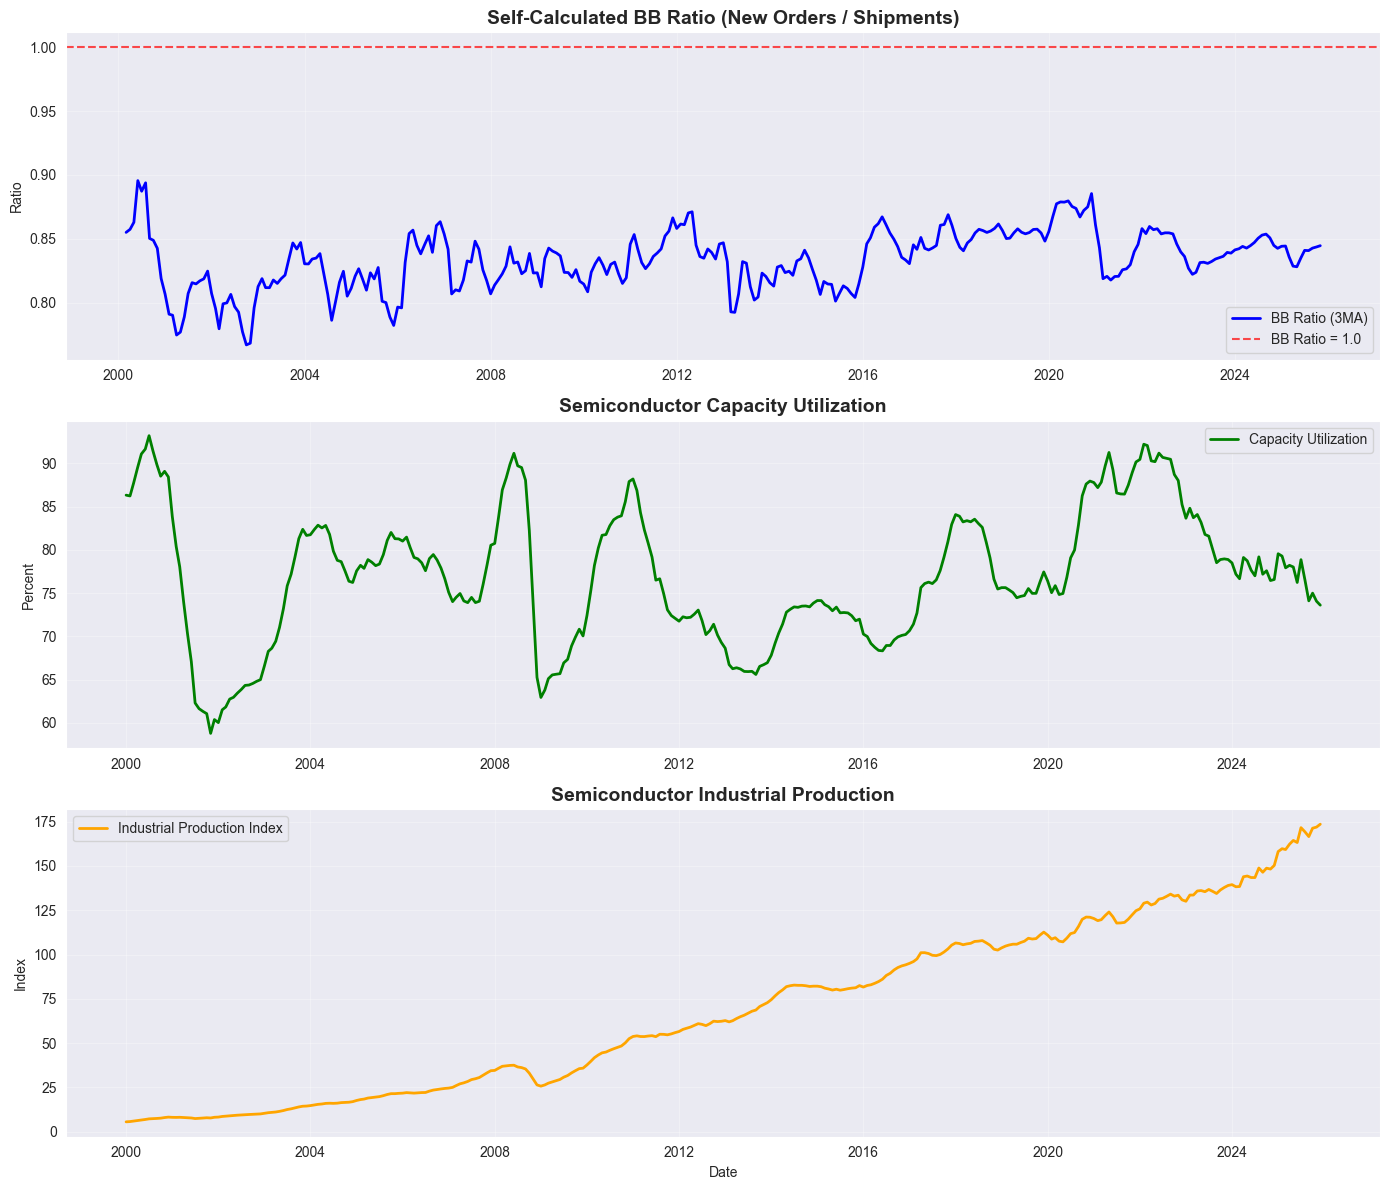


최근 데이터:
            capacity_utilization  industrial_production  new_orders  \
2025-01-01               79.5424               158.0732     26138.0   
2025-02-01               79.2698               159.6876     26187.0   
2025-03-01               77.9160               159.2281     25733.0   
2025-04-01               78.2049               162.2271     25858.0   
2025-05-01               78.0100               164.3526     26397.0   
2025-06-01               76.2240               163.1741     26639.0   
2025-07-01               78.8573               171.5555     26786.0   
2025-08-01               76.5406               169.2351     26485.0   
2025-09-01               74.1028               166.5202     26803.0   
2025-10-01               74.9894               171.2560     26863.0   
2025-11-01               74.0596               171.8663     26852.0   
2025-12-01               73.6016               173.5200         NaN   

            shipments  ppi_semiconductor  bb_ratio  bb_ratio_3ma  


In [9]:
from fredapi import Fred
import pandas as pd
from DATA.KEYS import KEYS
import matplotlib.pyplot as plt

API_KEY = KEYS['FRED']

# FRED API 키 발급: https://fred.stlouisfed.org/docs/api/api_key.html
fred = Fred(api_key=API_KEY)

# 모든 데이터 수집
print("데이터 다운로드 중...")
capacity_util = fred.get_series('CAPUTLG3344S', observation_start='2000-01-01')
production = fred.get_series('IPG3344S', observation_start='2000-01-01')
new_orders = fred.get_series('A34SNO', observation_start='2000-01-01')
shipments = fred.get_series('A34SVS', observation_start='2000-01-01')
ppi = fred.get_series('PCU33443344', observation_start='2000-01-01')

print(f"Capacity Utilization: {len(capacity_util)} rows")
print(f"Production: {len(production)} rows")
print(f"New Orders: {len(new_orders)} rows")
print(f"Shipments: {len(shipments)} rows")
print(f"PPI: {len(ppi)} rows")

# DataFrame 생성 (올바른 방법)
df = pd.DataFrame({
    'capacity_utilization': capacity_util,
    'industrial_production': production,
    'new_orders': new_orders,
    'shipments': shipments,
    'ppi_semiconductor': ppi
})

# BB ratio 계산
df['bb_ratio'] = df['new_orders'] / df['shipments']
df['bb_ratio_3ma'] = df['bb_ratio'].rolling(window=3).mean()
df['industrial_production_yoy_growth'] = df['industrial_production'].pct_change(12)

print("\n데이터 요약:")
print(df.describe())

# 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# BB Ratio
axes[0].plot(df.index, df['bb_ratio_3ma'], label='BB Ratio (3MA)', linewidth=2, color='blue')
axes[0].axhline(y=1.0, color='r', linestyle='--', label='BB Ratio = 1.0', alpha=0.7)
axes[0].set_title('Self-Calculated BB Ratio (New Orders / Shipments)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 반도체 가동률
axes[1].plot(df.index, df['capacity_utilization'], label='Capacity Utilization', linewidth=2, color='green')
axes[1].set_title('Semiconductor Capacity Utilization', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percent')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 산업생산
axes[2].plot(df.index, df['industrial_production'], label='Industrial Production Index', linewidth=2, color='orange')
axes[2].set_title('Semiconductor Industrial Production', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Index')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fred_semiconductor_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

# 최근 데이터 출력
print("\n최근 데이터:")
print(df.tail(12))

# CSV 저장
# df.to_csv('fred_semiconductor_data.csv')
# print("\nCSV 저장 완료: fred_semiconductor_data.csv")

<AxesSubplot: >

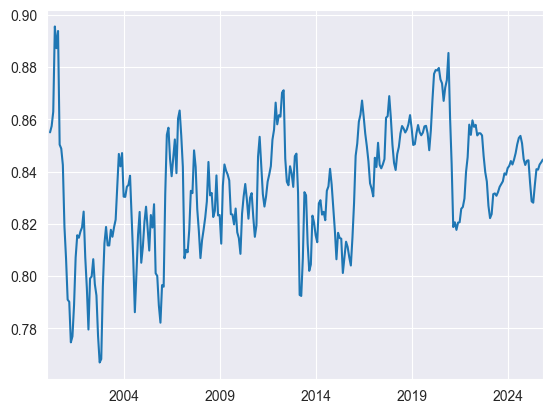

In [6]:
df['bb_ratio_3ma'].plot()

In [11]:
df['industrial_production_yoy_growth'] = df['industrial_production'].pct_change(12)

<AxesSubplot: >

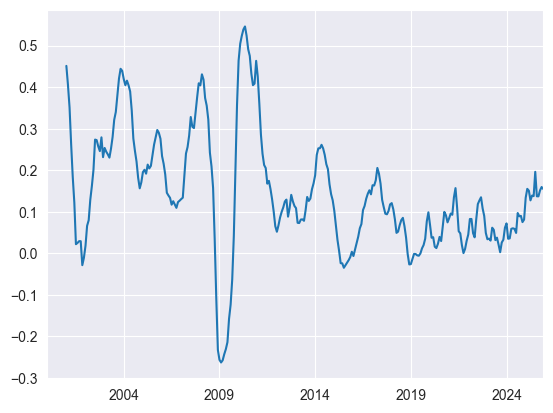

In [13]:
df['industrial_production_yoy_growth'].plot()